In [342]:
import os
import analysis_utils as au
import quick_metadata_plots as qmplt
import padeopsIO as pio
import matplotlib.pyplot as plt
import numpy as np
import streamtube
import pandas as pd
import seaborn as sns

sim_folder0 =  os.path.join(au.DATA_PATH, "F_0015_X_SU_PI_Files/")
sim_folder1 =  os.path.join(au.DATA_PATH, "F_0019_SU_PI_Files/")

%matplotlib inline

In [343]:
def get_uvel(folder):
    sim = pio.BudgetIO(folder, padeops = True, runid = 0, normalize_origin="turbine")
    tidx_vals, time_vals = sim.get_time_ax(return_tidx=True)
    # time_mask = time_vals > 100
    time_vals, tidx_vals = time_vals, tidx_vals
    # get all of the needed values
    uvel = sim.read_turb_uvel("all", turb=1)
    return time_vals, uvel

In [344]:
def get_vvel(folder):
    sim = pio.BudgetIO(folder, padeops = True, runid = 0, normalize_origin="turbine")
    tidx_vals, time_vals = sim.get_time_ax(return_tidx=True)
    # time_mask = time_vals > 100
    time_vals, tidx_vals = time_vals, tidx_vals
    # get all of the needed values
    vvel = sim.read_turb_vvel("all", turb=1)
    return time_vals, vvel

In [345]:
def get_power(folder):
    sim = pio.BudgetIO(folder, padeops = True, runid = 0, normalize_origin="turbine")
    tidx_vals, time_vals = sim.get_time_ax(return_tidx=True)
    # time_mask = time_vals > 100
    time_vals, tidx_vals = time_vals, tidx_vals
    # get all of the needed values
    power = sim.read_turb_power("all", turb=1)
    return time_vals, power

In [346]:
import re
from pathlib import Path
import numpy as np

def load_and_concat_pow(folder: str) -> np.ndarray:
    data_dir = Path(folder)
    pattern = re.compile(r"Run00_t(\d+)_turbP01\.pow$")
    files_with_t = []

    for f in data_dir.rglob("*.pow"):
        match = pattern.search(str(f))
        if match:
            timestep = int(match.group(1))
            files_with_t.append((timestep, f))

    files_with_t.sort(key=lambda x: x[0])
    vectors = [np.atleast_1d(np.loadtxt(filepath)) / (0.5 * np.pi * 0.5**2) for _, filepath in files_with_t]
    return np.concatenate(vectors)

In [347]:
def load_and_concat_uvel(folder: str) -> np.ndarray:
    data_dir = Path(folder)
    pattern = re.compile(r"Run00_t(\d+)_turbU01\.vel$")
    files_with_t = []

    for f in data_dir.rglob("*.vel"):
        match = pattern.search(str(f))
        if match:
            timestep = int(match.group(1))
            files_with_t.append((timestep, f))

    files_with_t.sort(key=lambda x: x[0])
    vectors = [np.atleast_1d(np.loadtxt(filepath)) for _, filepath in files_with_t]
    return np.concatenate(vectors)

In [348]:
def load_and_concat_vvel(folder: str) -> np.ndarray:
    data_dir = Path(folder)
    pattern = re.compile(r"Run00_t(\d+)_turbV01\.vel$")
    files_with_t = []

    for f in data_dir.rglob("*.vel"):
        match = pattern.search(str(f))
        if match:
            timestep = int(match.group(1))
            files_with_t.append((timestep, f))

    files_with_t.sort(key=lambda x: x[0])
    vectors = [np.atleast_1d(np.loadtxt(filepath)) for _, filepath in files_with_t]
    return np.concatenate(vectors)

# Test Kirby PR

Note that budgets are off for these simulations!

In [349]:
# not moving turbines
stationary0 = au.get_run_folder(sim_folder0, 0)
stationary0_time, stationary0_uvel = get_uvel(stationary0)

stationary1 = au.get_run_folder(sim_folder1, 0)
stationary1_time, stationary1_uvel = get_uvel(stationary1)

stationary2 = au.get_run_folder(sim_folder1, 3)
stationary2_time, stationary2_uvel = get_uvel(stationary2)

0
0


3


In [350]:
len(stationary0_time), len(stationary0_uvel), len(stationary1_time), len(stationary1_uvel), len(stationary2_time), len(stationary2_uvel)

(3227, 3227, 4001, 4001, 4001, 4001)

In [351]:
# surging turbines
surging0 = au.get_run_folder(sim_folder0, 1)
surging0_time, surging0_uvel = get_uvel(surging0)

surging1 = au.get_run_folder(sim_folder1, 1)
surging1_time, surging1_uvel = get_uvel(surging1)

surging2 = au.get_run_folder(sim_folder1, 4)
surging2_time, surging2_uvel = get_uvel(surging2)

1
1


4


In [352]:
len(surging0_time), len(surging0_uvel), len(surging1_time), len(surging1_uvel), len(surging2_time), len(surging2_uvel)

(3227, 3227, 4001, 4001, 4001, 4001)

In [353]:
# pitching turbines
pitching0 = au.get_run_folder(sim_folder0, 2)
pitching0_time, pitching0_uvel = get_uvel(pitching0)

pitching1 = au.get_run_folder(sim_folder1, 2)
pitching1_time, pitching1_uvel = get_uvel(pitching1)

pitching2 = au.get_run_folder(sim_folder1, 5)
pitching2_time, pitching2_uvel = get_uvel(pitching2)

2


2
5


In [354]:
len(pitching0_time), len(pitching0_uvel), len(pitching1_time), len(pitching1_uvel), len(pitching2_time), len(pitching2_uvel)

(3227, 3227, 4001, 4001, 4001, 4001)

In [355]:
diff_stationary = (stationary2_uvel - stationary1_uvel) / stationary1_uvel * 100
diff_surging = (surging2_uvel - surging1_uvel) / surging1_uvel * 100
diff_pitching = (pitching2_uvel - pitching1_uvel) / pitching1_uvel * 100

Text(0, 0.5, '$u$')

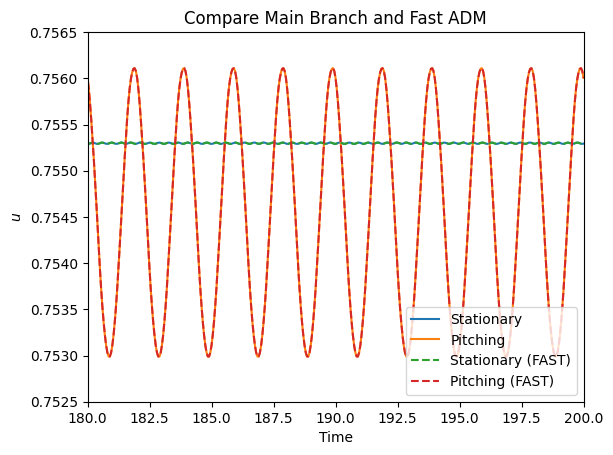

In [356]:
plt.plot(stationary2_time, stationary1_uvel, label = "Stationary")
# plt.plot(surging2_time, surging1_uvel, label = "Surging")
plt.plot(pitching2_time, pitching1_uvel, label = "Pitching")

plt.plot(stationary2_time, stationary2_uvel, label = "Stationary (FAST)", linestyle = "--")
# plt.plot(surging2_time, surging2_uvel, label = "Surging (FAST)", linestyle = "--")
plt.plot(pitching2_time, pitching2_uvel, label = "Pitching (FAST)", linestyle = "--")

plt.legend(loc = "lower right")
plt.xlim(180, 200)
plt.ylim(0.7525, 0.7565)
plt.title("Compare Main Branch and Fast ADM")
plt.xlabel("Time")
plt.ylabel("$u$")

Text(0, 0.5, 'Difference between Main branch and FAST $u$ (%)')

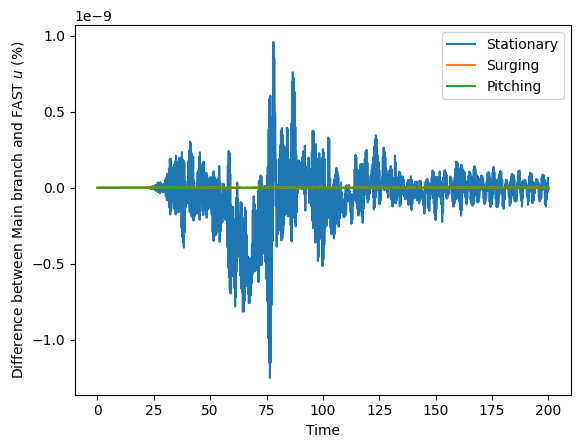

In [357]:
plt.plot(stationary2_time, diff_stationary, label = "Stationary")
plt.plot(surging2_time, diff_surging, label = "Surging")
plt.plot(pitching2_time, diff_pitching, label = "Pitching")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Difference between Main branch and FAST $u$ (%)")

In [358]:
surging1 = au.get_run_folder(sim_folder1, 1)
surging1_power = load_and_concat_pow(surging1)

surging2 = au.get_run_folder(sim_folder1, 4)
surging2_power = load_and_concat_pow(surging2)

len(surging1_power), len(surging2_power)

1
4


(4001, 4001)

Text(0.5, 0, 'Timestep')

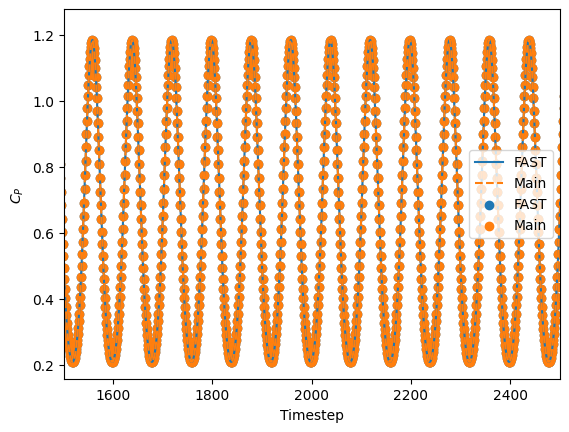

In [359]:
xs = range(0, 4001)
plt.plot(xs, surging1_power, label = "FAST")
plt.plot(xs, surging2_power, label = "Main", linestyle = "--")
plt.scatter(xs, surging1_power, label = "FAST")
plt.scatter(xs, surging2_power, label = "Main")
plt.xlim(1500, 2500)
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Timestep")

# Test Weird Extra Power/Velocity values with Budgets

In [360]:
import re
from pathlib import Path
import numpy as np

def load_and_concat_pow(folder: str) -> np.ndarray:
    data_dir = Path(folder)
    pattern = re.compile(r"Run00_t(\d+)_turbP01\.pow$")
    files_with_t = []

    for f in data_dir.rglob("*.pow"):
        match = pattern.search(str(f))
        if match:
            timestep = int(match.group(1))
            files_with_t.append((timestep, f))

    files_with_t.sort(key=lambda x: x[0])
    vectors = [np.atleast_1d(np.loadtxt(filepath)) for _, filepath in files_with_t]
    return np.concatenate(vectors)

There should be 4000 timesteps, but with the budget on, there were orginally 6000 timesteps due to repreated timesteps! This is now fixed.

In [361]:
200 / 0.05

4000.0

## Stationary

In [362]:
stationary2_power = load_and_concat_pow(stationary2)
len(stationary2_power) # 4000 values when budgets are off

4001

In [363]:
stationary3 = au.get_run_folder(sim_folder1, 6) # FAST
stationary3_power = load_and_concat_pow(stationary3)

stationary4 = au.get_run_folder(sim_folder1, 9) # MAIN
stationary4_power = load_and_concat_pow(stationary4)

stationary5 = au.get_run_folder(sim_folder1, 12) # Fixed repeate budget + FAST
stationary5_power = load_and_concat_pow(stationary5)
# 6000 values when budgets are on, except for last one which is fixed!
len(stationary3_power), len(stationary4_power), len(stationary5_power)

6
9
12


(6000, 6000, 4001)

## Surging

In [364]:
surging2_power = load_and_concat_pow(surging2)
len(surging2_power) # 4000 values when budgets are off

4001

In [365]:
surging3 = au.get_run_folder(sim_folder1, 7) # FAST
surging3_power = load_and_concat_pow(surging3)

surging4 = au.get_run_folder(sim_folder1, 10) # MAIN
surging4_power = load_and_concat_pow(surging4)

surging5 = au.get_run_folder(sim_folder1, 13) # Fixed repeate budget + FAST
surging5_power = load_and_concat_pow(surging5)
# 6000 values when budgets are on, except for last one which is fixed!
len(surging3_power), len(surging4_power), len(surging5_power)

7
10
13


(6000, 6000, 4001)

Text(0.5, 0, 'Timestep')

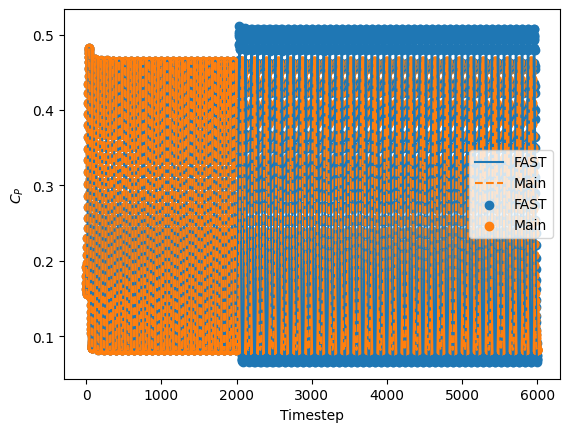

In [366]:
# when budgets turned on, turbines were moving at 2x speed bc fix (PR#7) wasn't integrated into branch 
xs = range(0, 6000)
plt.plot(xs, surging3_power, label = "FAST")
plt.plot(xs, surging4_power, label = "Main", linestyle = "--")
plt.scatter(xs, surging3_power, label = "FAST")
plt.scatter(xs, surging4_power, label = "Main")
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Timestep")

Text(0.5, 0, 'Timestep')

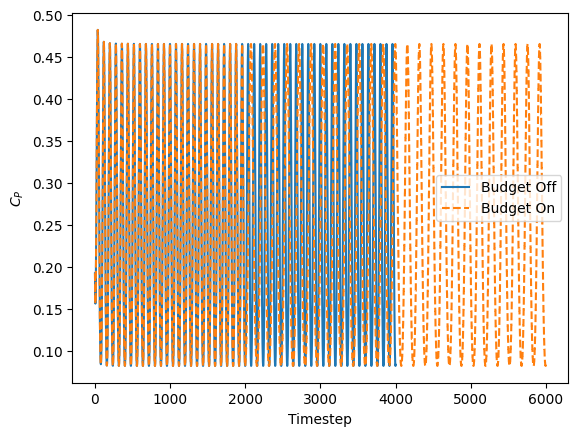

In [367]:
plt.plot(range(0, 4001), surging2_power, label = "Budget Off")
plt.plot(range(0, 6000), surging4_power, label = "Budget On", linestyle = "--")
# plt.xlim(1500, 4500)
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Timestep")

Text(0.5, 0, 'Timestep')

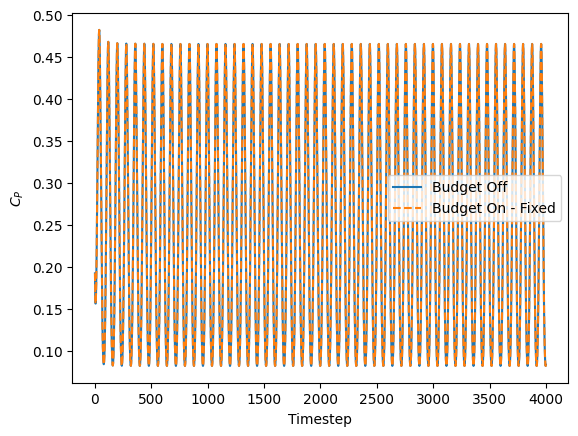

In [368]:
# with PR#7 merged and fix to double printing, values match with when budget is off!
xs = range(0, 4001)
plt.plot(xs, surging2_power, label = "Budget Off")
plt.plot(xs, surging5_power, label = "Budget On - Fixed", linestyle = "--")
# plt.scatter(xs, surging2_power, label = "Budget Off")
# plt.scatter(xs, surging5_power, label = "Budget On - Fixed")
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Timestep")

Text(0.5, 0, 'Time')

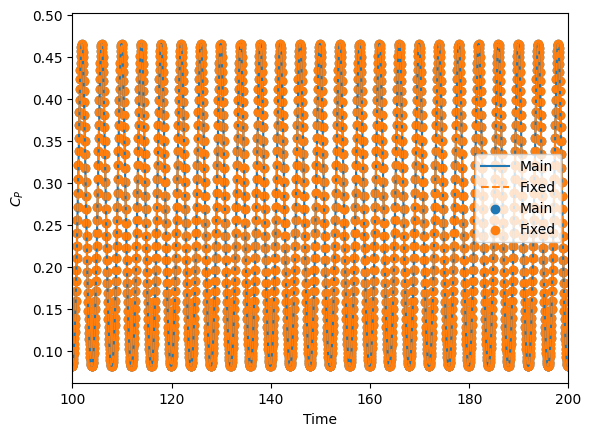

In [369]:
# using PIO, we can see that with double values filtered from surging4, values match fixed surging5
time_vals4_pio, power4_pio = get_power(surging4)
xs5 = np.linspace(0, 200, num = 4001)

plt.plot(time_vals4_pio, power4_pio, label = "Main")
plt.plot(xs5, surging5_power, label = "Fixed", linestyle = "--")
plt.scatter(time_vals4_pio, power4_pio, label = "Main")
plt.scatter(xs5, surging5_power, label = "Fixed")
plt.xlim(100, 200)
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Time")

In [370]:
surging5_uvel = load_and_concat_uvel(surging5)
surging5_vvel = load_and_concat_uvel(surging5)
len(surging5_uvel), len(surging5_vvel) # also doesn't double write velocities now!

(4001, 4001)

Text(0.5, 0, 'Time')

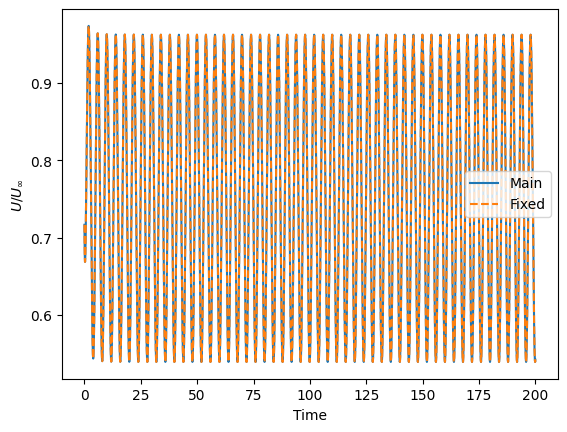

In [371]:
# using PIO, we can see that with double values filtered from surging4, values match fixed surging5
time_vals4_pio, uvel4_pio = get_uvel(surging4)
xs5 = np.linspace(0, 200, num = 4001)

plt.plot(time_vals4_pio, uvel4_pio, label = "Main")
plt.plot(xs5, surging5_uvel, label = "Fixed", linestyle = "--")
# plt.scatter(time_vals4_pio, uvel4_pio, label = "Main")
# plt.scatter(xs5, surging5_uvel, label = "Fixed")
# plt.xlim(150, 200)
plt.legend()
plt.ylabel("$U/U_\infty$")
plt.xlabel("Time")

## Pitching

In [372]:
pitching2_power = load_and_concat_pow(pitching2)
len(pitching2_power)

4001

In [373]:
pitching3 = au.get_run_folder(sim_folder1, 8) # FAST
pitching3_power = load_and_concat_pow(pitching3)

pitching4 = au.get_run_folder(sim_folder1, 11) # MAIN
pitching4_power = load_and_concat_pow(pitching4)

pitching5 = au.get_run_folder(sim_folder1, 14) # FIXED (FAST + fix double print)
pitching5_power = load_and_concat_pow(pitching5)

len(pitching3_power), len(pitching4_power), len(pitching5_power)

8
11
14


(6000, 6000, 4001)

Text(0.5, 0, 'Timestep')

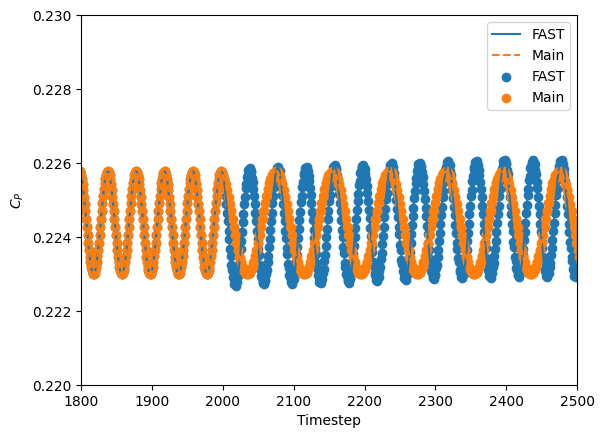

In [374]:
# when budgets turned on, turbines were moving at 2x speed bc fix (PR#7) wasn't integrated into branch 
xs = range(0, 6000)
plt.plot(xs, pitching3_power, label = "FAST")
plt.plot(xs, pitching4_power, label = "Main", linestyle = "--")
plt.scatter(xs, pitching3_power, label = "FAST")
plt.scatter(xs, pitching4_power, label = "Main")
plt.xlim(1800, 2500)
plt.ylim(0.22, 0.23)
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Timestep")

Text(0.5, 0, 'Timestep')

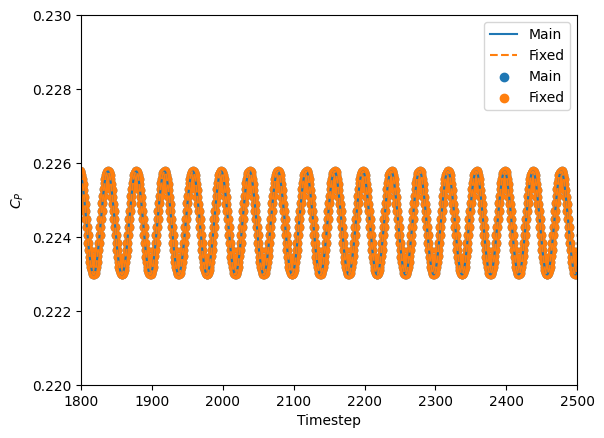

In [375]:
# with PR#7 merged and fix to double printing, values match with when budget is off!
xs = range(0, 4001)
plt.plot(xs, pitching2_power, label = "Main")
plt.plot(xs, pitching5_power, label = "Fixed", linestyle = "--")
plt.scatter(xs, pitching2_power, label = "Main")
plt.scatter(xs, pitching5_power, label = "Fixed")
plt.xlim(1800, 2500)
plt.ylim(0.22, 0.23)
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Timestep")

Text(0.5, 0, 'Time')

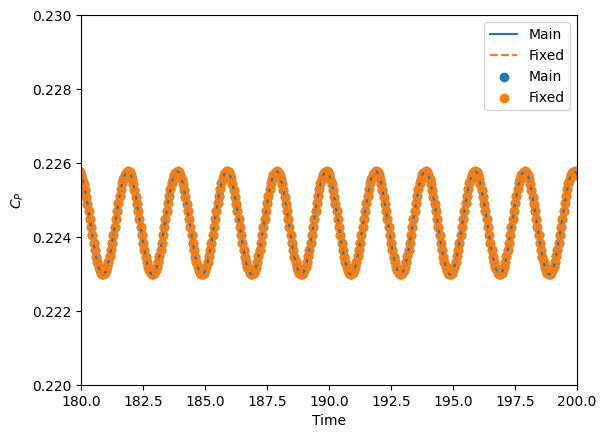

In [376]:
# using PIO, we can see that with double values filtered from surging4, values match fixed surging5
time_vals4_pio, power4_pio = get_power(pitching4)
xs5 = np.linspace(0, 200, num = 4001)

plt.plot(time_vals4_pio, power4_pio, label = "Main")
plt.plot(xs5, pitching5_power, label = "Fixed", linestyle = "--")
plt.scatter(time_vals4_pio, power4_pio, label = "Main")
plt.scatter(xs5, pitching5_power, label = "Fixed")
plt.xlim(180, 200)
plt.ylim(0.22, 0.23)
plt.legend()
plt.ylabel("$C_P$")
plt.xlabel("Time")